In [1]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [2]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 720
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19443.    27359.5  -26523.5   29186.    10360.5   27538.5  -17840.5
  28326.   -10662.5   28418.5    3473.    27876.   -27267.5   29836.5
  21314.    27976.5  -27920.5   29951.5   23421.5   28214.   -12034.
  28774.     8556.    28492.5   10305.5   27996.5  -13423.    29077.
  21867.    27914.   -25387.5   29809.5   14391.5   28174.   -20535.5
  29352.5   20802.5   27697.   -27617.    29505.     9551.    28000.5
 -17167.5   28696.   -12391.5   28871.5    4892.5   28166.   -28211.
  30113.5   21892.5   28098.5  -27316.    29949.    22458.    28215.
 -10273.    28577.5    6538.5   28392.    11477.    27759.   -14727.5
  28943.     -867.5   29043.    -3647.    29198.    18165.5   28361.5
 -23641.    29681.5   22278.    28083.   -28827.    29929.     8984.
  28448.   -16566.    29038.   -13928.    29321.5    6282.    28442.5
 -28623.5   30393.    22020.    28267.5  -26182.    30032.    20955.
  28281.    -8140.    28472.     3993.5   28344.5  -16823.    29

In [3]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

5.82 µs ± 990 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [4]:
# Loading in previous fit from vampires_calibration
from pathlib import Path

fallback_filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/725-50_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt"
saved_fit_filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"

if Path(saved_fit_filename).exists():
    filename = saved_fit_filename
    print("Resuming from saved MBI scipy.minimize fit: " + filename)
else:
    filename = fallback_filename
    print("Starting from closest broadband filter fit: " + filename)
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
dichroic_phi = past_fit.get("dichroic", {}).get("phi", 0)
dichroic_epsilon = past_fit.get("dichroic", {}).get("epsilon", 0)
dichroic_theta = past_fit.get("dichroic", {}).get("theta", 0)
em_gain = 1.0  # Fixed ideal EM gain

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": dichroic_phi, "epsilon": dichroic_epsilon, "theta": dichroic_theta},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

Starting from closest broadband filter fit: /home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/725-50_no_IMR_offset_iterate_on_any_improvement_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values_EM_gain_1.txt
{'dichroic': {'phi': -0.0314819168393862, 'epsilon': 0.375214591622026, 'theta': -37.86709032794474}, 'flc': {'phi': 3.229205759656426, 'delta_theta': 4.9999999997504885}, 'optics': {'phi': 0.3500619624227417, 'epsilon': 0.0028623469769647, 'theta': -48.400567534857046}, 'image_rotator': {'phi': 2.7596852675586145}, 'hwp': {'phi': 2.9980588095949106, 'delta_theta': 1.8731071974285654}, 'lp': {'theta': 4.999999989826851}}


In [5]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.47104009 0.46388393 0.08179525 0.        ]
 [0.47104009 0.46388393 0.08179525 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -0.0314819168393862, 'epsilon': 0.375214591622026, 'theta': -37.86709032794474}, 'flc': {'phi': 3.229205759656426, 'delta_theta': 4.9999999997504885}, 'optics': {'phi': 0.3500619624227417, 'epsilon': 0.0028623469769647, 'theta': -48.400567534857046}, 'image_rotator': {'phi': 2.7596852675586145}, 'hwp': {'phi': 2.9980588095949106, 'delta_theta': 1.8731071974285654}, 'lp': {'theta': 4.999999989826851}}
logl value: 6343.798131786758


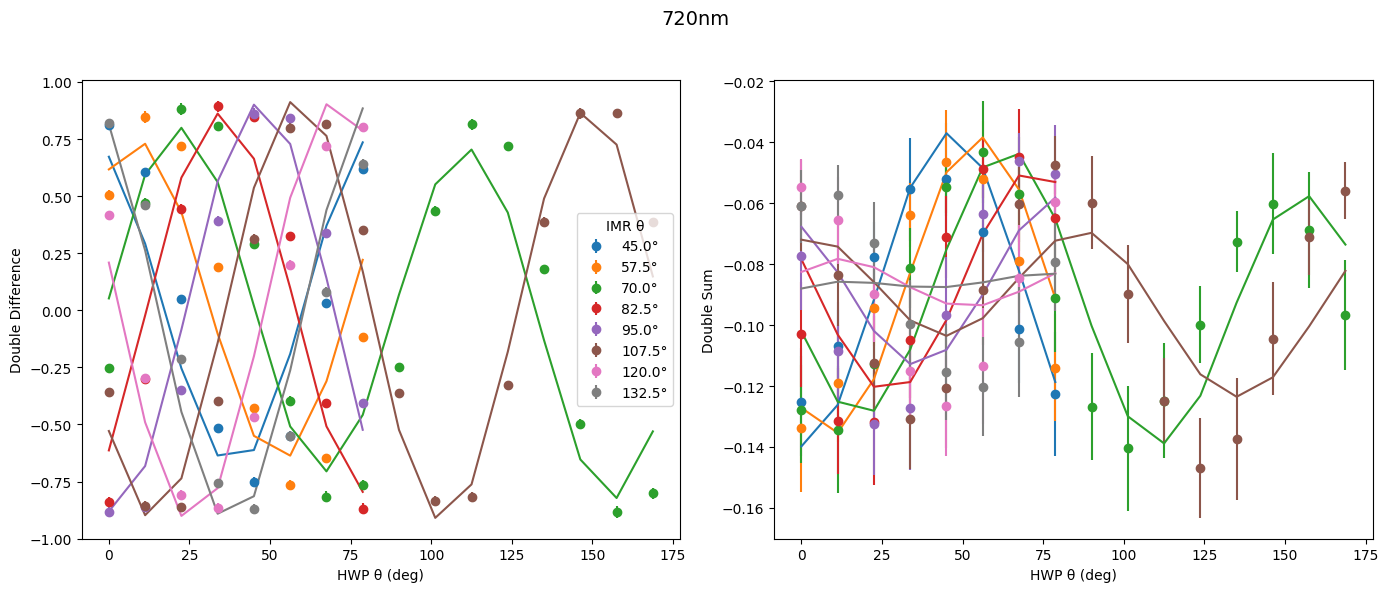

In [6]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -0.0314819168393862, 'epsilon': 0.375214591622026, 'theta': -37.86709032794474}, 'flc': {'phi': 3.229205759656426, 'delta_theta': 4.9999999997504885}, 'optics': {'phi': 0.3500619624227417, 'epsilon': 0.0028623469769647, 'theta': -48.400567534857046}, 'image_rotator': {'phi': 2.7596852675586145}, 'hwp': {'phi': 2.9980588095949106, 'delta_theta': 1.8731071974285654}, 'lp': {'theta': 4.999999989826851}}
Iteration #: 1
logl_value: 17.263970004674494
Best Fit Parameters: [-6.70794257e-02  3.05755901e-01 -3.61020680e+01  3.15246760e+00
  1.23152493e+00  2.26478142e-01  2.65677648e-03  3.19186276e+00
  2.62573437e+00  2.99252707e+00 -2.02106755e-01  3.31289842e+00]
After p0: {'dichroic': {'phi': -0.06707942567441971, 'epsilon': 0.30575590071944014, 'theta': -36.102068018602324}, 'flc': {'phi': 3.152467599730265, 'delta_theta': 1.2315249305071307}, 'optics': {'phi': 0.22647814201886668, 'epsilon': 0.0026567764817884082, 'theta': 3.191862762037271}, 'image_rotato

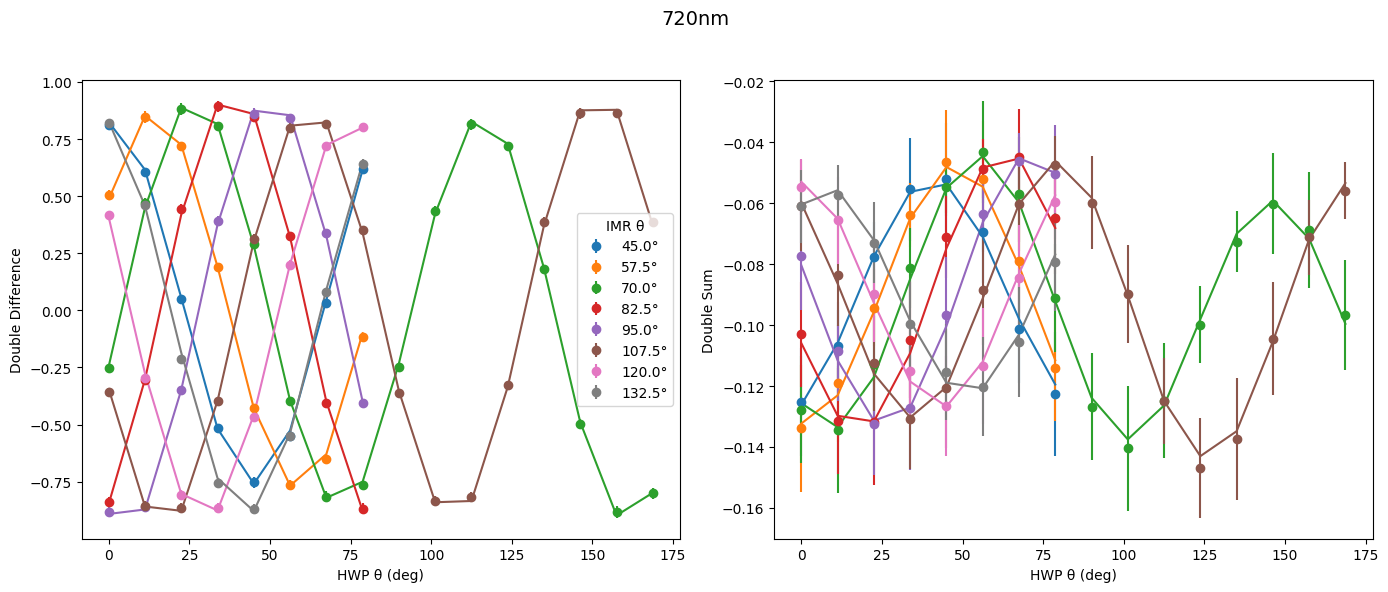

Before p0: {'dichroic': {'phi': -0.06707942567441971, 'epsilon': 0.30575590071944014, 'theta': -36.102068018602324}, 'flc': {'phi': 3.152467599730265, 'delta_theta': 1.2315249305071307}, 'optics': {'phi': 0.22647814201886668, 'epsilon': 0.0026567764817884082, 'theta': 3.191862762037271}, 'image_rotator': {'phi': 2.6257343732902507}, 'hwp': {'phi': 2.992527066292893, 'delta_theta': -0.20210675484550128}, 'lp': {'theta': 3.3128984150357477}}
Iteration #: 2
logl_value: 15.910275046040738
Best Fit Parameters: [-3.66111174e-02  3.09615116e-01 -3.62029358e+01  3.20827001e+00
  1.31402152e+00  2.12829781e-01  4.50949735e-03  3.69728029e-02
  2.62621275e+00  2.98878335e+00 -2.04070050e+00 -1.22159816e-01]
After p0: {'dichroic': {'phi': -0.036611117367138735, 'epsilon': 0.3096151159351759, 'theta': -36.20293584912993}, 'flc': {'phi': 3.2082700129700568, 'delta_theta': 1.3140215214645958}, 'optics': {'phi': 0.21282978139823033, 'epsilon': 0.004509497347319666, 'theta': 0.03697280292078908}, 'ima

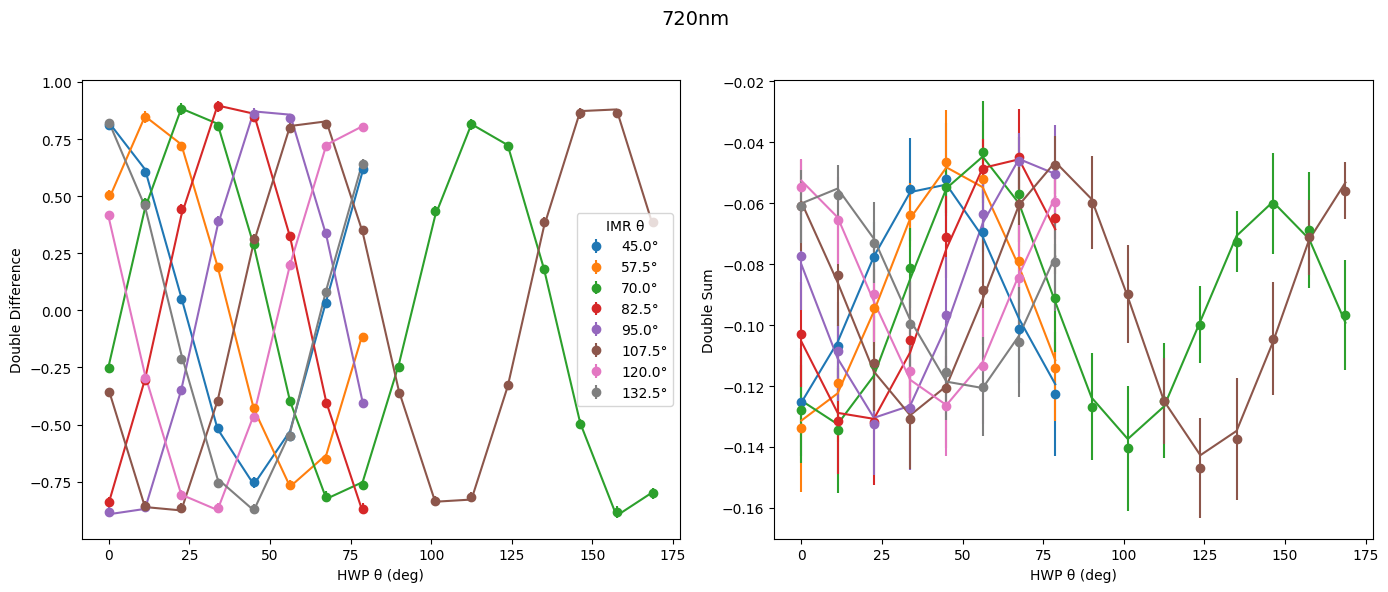

Before p0: {'dichroic': {'phi': -0.036611117367138735, 'epsilon': 0.3096151159351759, 'theta': -36.20293584912993}, 'flc': {'phi': 3.2082700129700568, 'delta_theta': 1.3140215214645958}, 'optics': {'phi': 0.21282978139823033, 'epsilon': 0.004509497347319666, 'theta': 0.03697280292078908}, 'image_rotator': {'phi': 2.626212749336088}, 'hwp': {'phi': 2.9887833463417444, 'delta_theta': -2.0407004992286115}, 'lp': {'theta': -0.12215981634293727}}
Iteration #: 3
logl_value: 15.910273260000011
Best Fit Parameters: [-3.66219473e-02  3.09610251e-01 -3.62028798e+01  3.20825030e+00
  1.31403745e+00  2.12843178e-01  4.51027647e-03  3.93713328e-02
  2.62621203e+00  2.98878069e+00 -2.04033882e+00 -1.21440881e-01]
After p0: {'dichroic': {'phi': -0.03662194731672054, 'epsilon': 0.30961025098398176, 'theta': -36.20287976708869}, 'flc': {'phi': 3.208250298815682, 'delta_theta': 1.3140374491202476}, 'optics': {'phi': 0.21284317802292446, 'epsilon': 0.004510276466183296, 'theta': 0.03937133279811697}, 'im

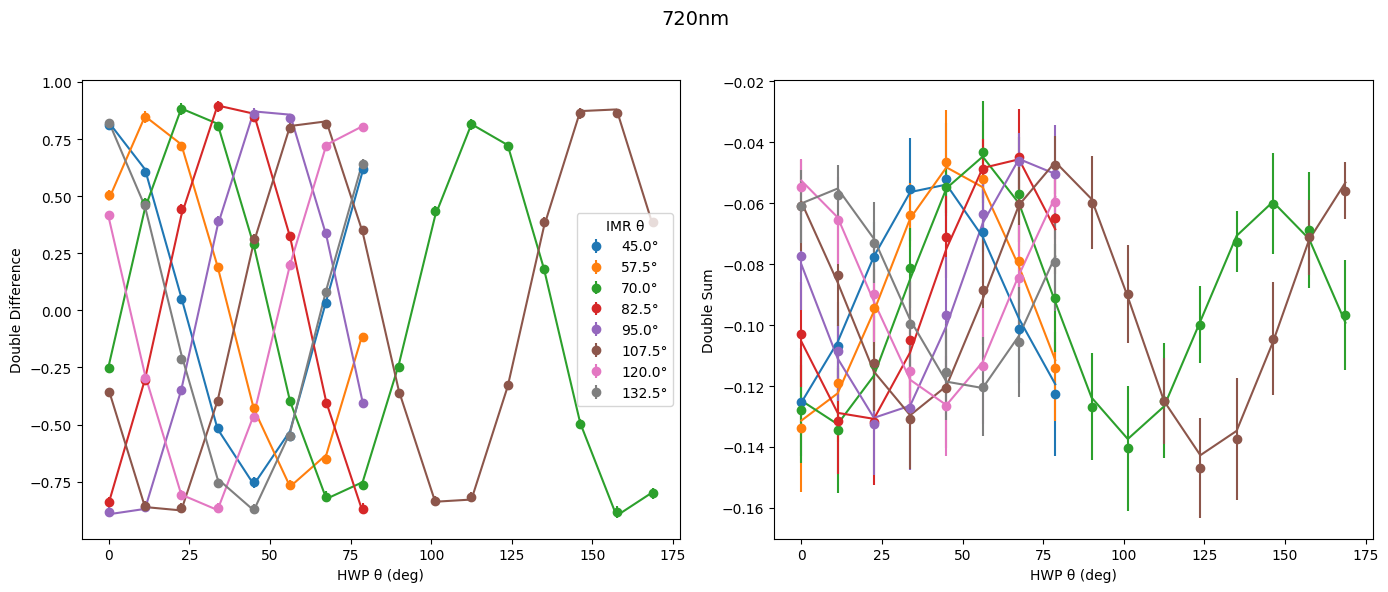

Before p0: {'dichroic': {'phi': -0.03662194731672054, 'epsilon': 0.30961025098398176, 'theta': -36.20287976708869}, 'flc': {'phi': 3.208250298815682, 'delta_theta': 1.3140374491202476}, 'optics': {'phi': 0.21284317802292446, 'epsilon': 0.004510276466183296, 'theta': 0.03937133279811697}, 'image_rotator': {'phi': 2.6262120251301675}, 'hwp': {'phi': 2.988780687375062, 'delta_theta': -2.0403388173575925}, 'lp': {'theta': -0.12144088073783679}}
Iteration #: 4
logl_value: 15.910273238944344
Best Fit Parameters: [-3.66201351e-02  3.09611582e-01 -3.62029159e+01  3.20825379e+00
  1.31407548e+00  2.12842774e-01  4.51035289e-03  3.94175188e-02
  2.62621265e+00  2.98878014e+00 -2.04038715e+00 -1.21440584e-01]
After p0: {'dichroic': {'phi': -0.03662013511555465, 'epsilon': 0.3096115816863111, 'theta': -36.202915889694864}, 'flc': {'phi': 3.2082537922232532, 'delta_theta': 1.31407548442639}, 'optics': {'phi': 0.21284277363181198, 'epsilon': 0.004510352892215196, 'theta': 0.039417518848608904}, 'ima

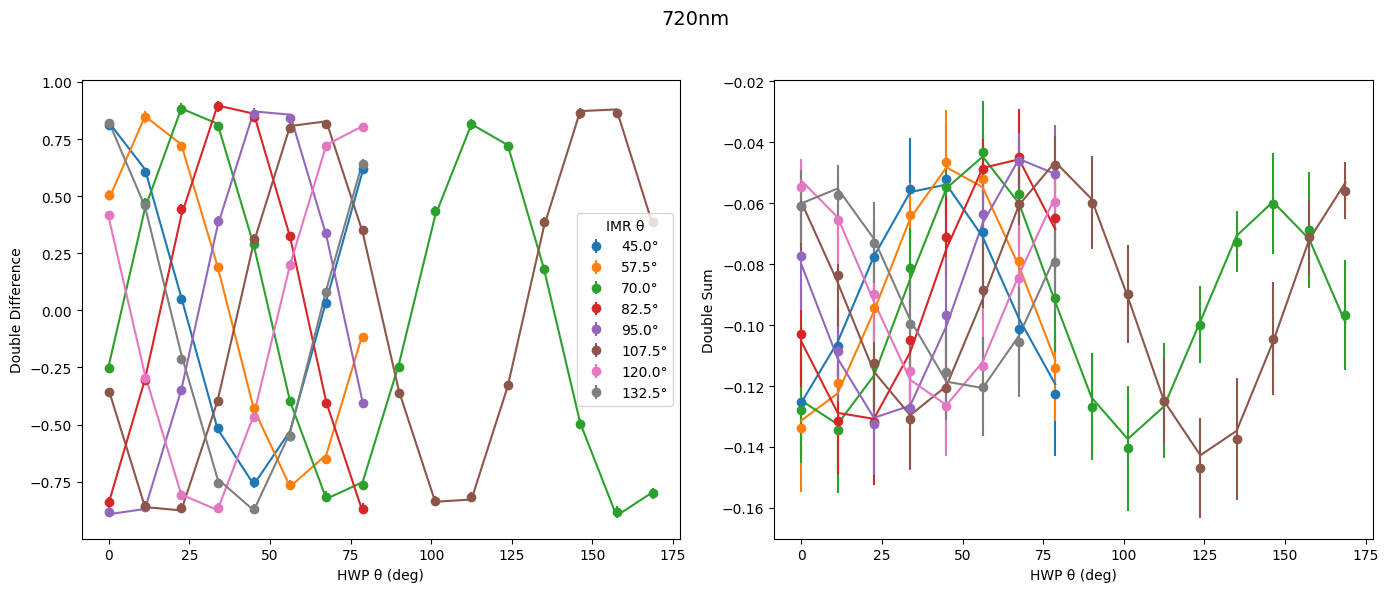

Before p0: {'dichroic': {'phi': -0.03662013511555465, 'epsilon': 0.3096115816863111, 'theta': -36.202915889694864}, 'flc': {'phi': 3.2082537922232532, 'delta_theta': 1.31407548442639}, 'optics': {'phi': 0.21284277363181198, 'epsilon': 0.004510352892215196, 'theta': 0.039417518848608904}, 'image_rotator': {'phi': 2.6262126533774985}, 'hwp': {'phi': 2.9887801357515302, 'delta_theta': -2.0403871523153727}, 'lp': {'theta': -0.12144058401205561}}
Iteration #: 5
logl_value: 15.910273224870746
Best Fit Parameters: [-3.66197553e-02  3.09611895e-01 -3.62029266e+01  3.20825377e+00
  1.31408622e+00  2.12847762e-01  4.51053663e-03  3.94310689e-02
  2.62621306e+00  2.98878008e+00 -2.04035579e+00 -1.21349995e-01]
After p0: {'dichroic': {'phi': -0.03661975525856917, 'epsilon': 0.3096118954473359, 'theta': -36.202926638134244}, 'flc': {'phi': 3.2082537681086842, 'delta_theta': 1.3140862187228115}, 'optics': {'phi': 0.21284776230144176, 'epsilon': 0.004510536631016098, 'theta': 0.03943106888290113}, 'i

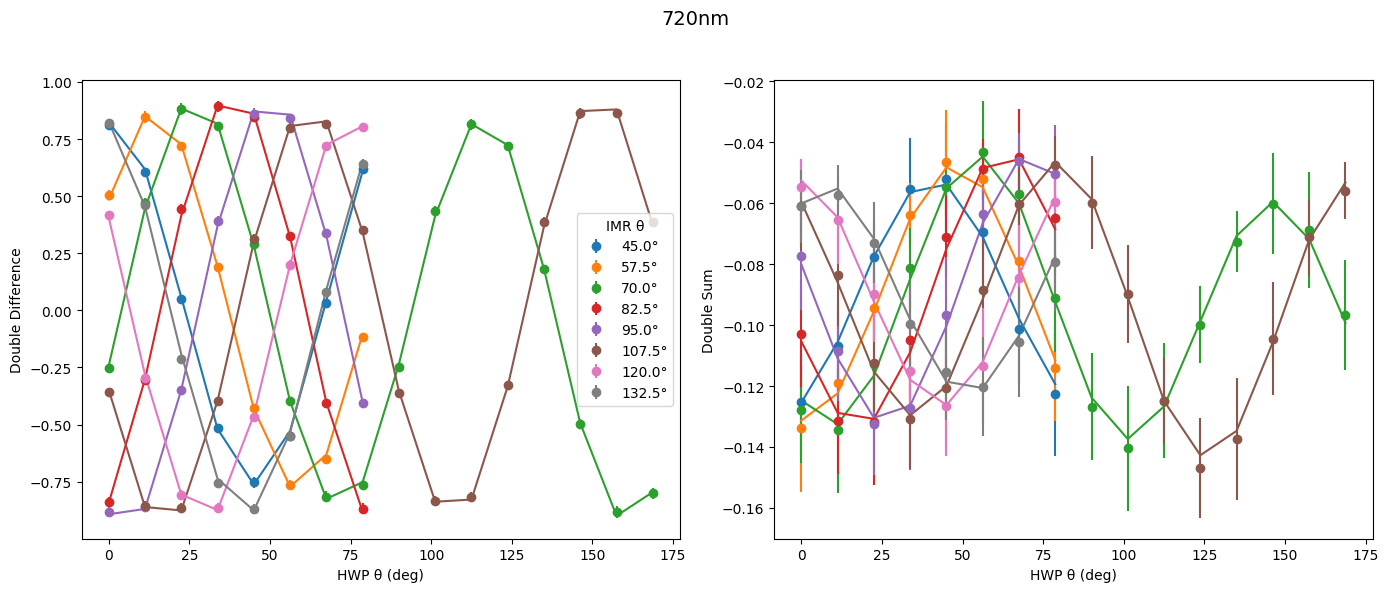

Before p0: {'dichroic': {'phi': -0.03661975525856917, 'epsilon': 0.3096118954473359, 'theta': -36.202926638134244}, 'flc': {'phi': 3.2082537681086842, 'delta_theta': 1.3140862187228115}, 'optics': {'phi': 0.21284776230144176, 'epsilon': 0.004510536631016098, 'theta': 0.03943106888290113}, 'image_rotator': {'phi': 2.6262130621789446}, 'hwp': {'phi': 2.98878007784319, 'delta_theta': -2.0403557918710202}, 'lp': {'theta': -0.12134999480762672}}
Iteration #: 6
logl_value: 15.910273205918049
Best Fit Parameters: [-3.66194895e-02  3.09612072e-01 -3.62029329e+01  3.20825498e+00
  1.31408266e+00  2.12841293e-01  4.51052908e-03  3.93544881e-02
  2.62621307e+00  2.98877979e+00 -2.04035551e+00 -1.21351927e-01]
After p0: {'dichroic': {'phi': -0.03661948947695848, 'epsilon': 0.30961207185504613, 'theta': -36.202932857196004}, 'flc': {'phi': 3.208254979942477, 'delta_theta': 1.3140826623269664}, 'optics': {'phi': 0.21284129348897002, 'epsilon': 0.00451052908398239, 'theta': 0.039354488132951726}, 'im

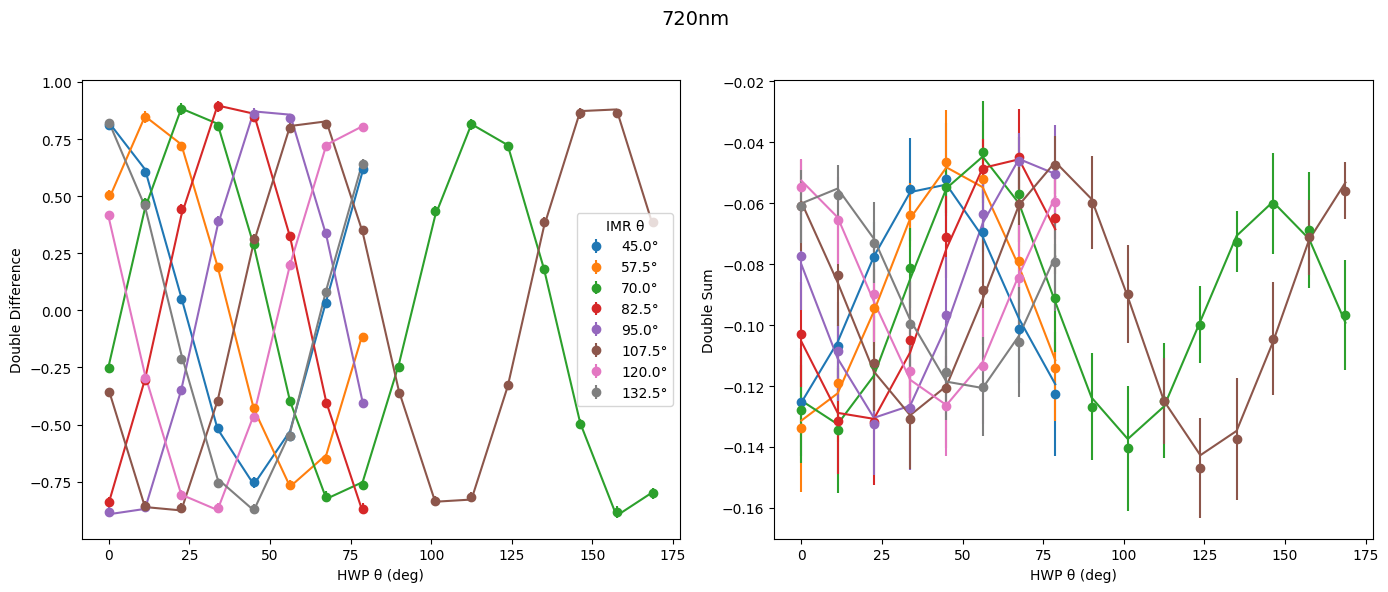

Before p0: {'dichroic': {'phi': -0.03661948947695848, 'epsilon': 0.30961207185504613, 'theta': -36.202932857196004}, 'flc': {'phi': 3.208254979942477, 'delta_theta': 1.3140826623269664}, 'optics': {'phi': 0.21284129348897002, 'epsilon': 0.00451052908398239, 'theta': 0.039354488132951726}, 'image_rotator': {'phi': 2.6262130733408107}, 'hwp': {'phi': 2.9887797912603427, 'delta_theta': -2.0403555126697253}, 'lp': {'theta': -0.12135192673922983}}
Iteration #: 7
logl_value: 15.91027311166824
Best Fit Parameters: [-3.66097824e-02  3.09613350e-01 -3.62029671e+01  3.20827388e+00
  1.31408952e+00  2.12835203e-01  4.51051169e-03  3.80984108e-02
  2.62621282e+00  2.98877926e+00 -2.04032440e+00 -1.21264231e-01]
After p0: {'dichroic': {'phi': -0.03660978235637999, 'epsilon': 0.30961334958724407, 'theta': -36.20296712937699}, 'flc': {'phi': 3.2082738835826516, 'delta_theta': 1.3140895175005483}, 'optics': {'phi': 0.21283520327411676, 'epsilon': 0.004510511693434968, 'theta': 0.038098410778295747}, '

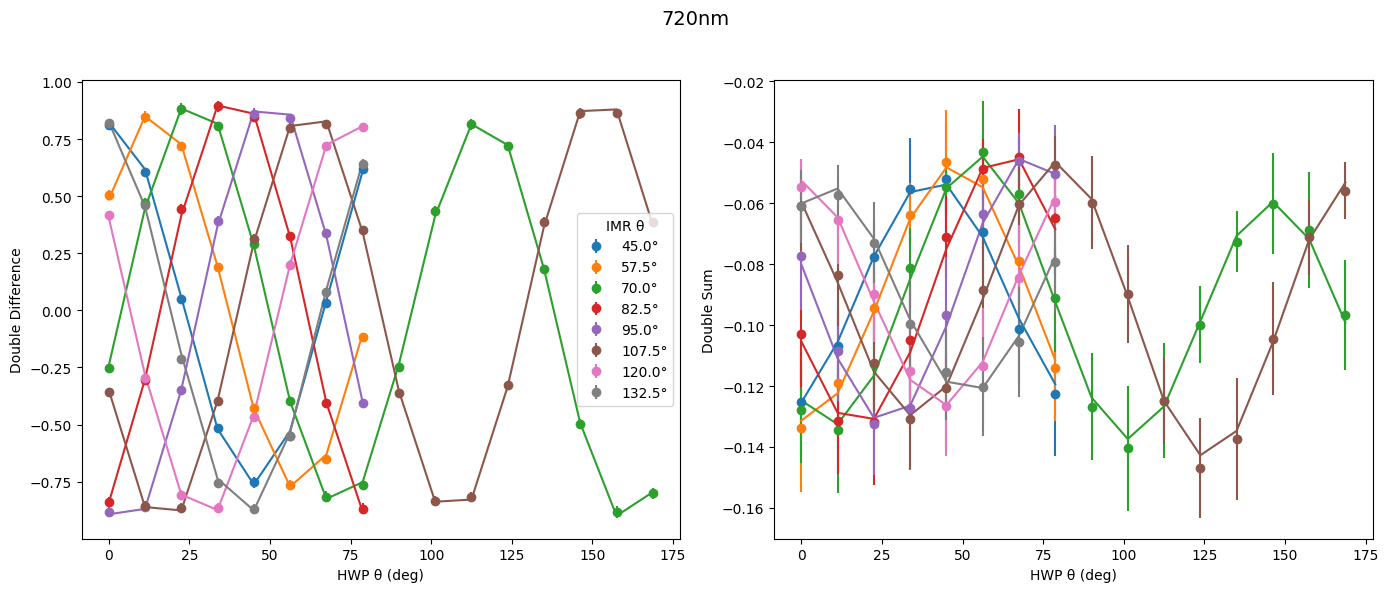

Before p0: {'dichroic': {'phi': -0.03660978235637999, 'epsilon': 0.30961334958724407, 'theta': -36.20296712937699}, 'flc': {'phi': 3.2082738835826516, 'delta_theta': 1.3140895175005483}, 'optics': {'phi': 0.21283520327411676, 'epsilon': 0.004510511693434968, 'theta': 0.038098410778295747}, 'image_rotator': {'phi': 2.626212815242026}, 'hwp': {'phi': 2.988779261886696, 'delta_theta': -2.0403244016973296}, 'lp': {'theta': -0.12126423070405389}}
Iteration #: 8
logl_value: 15.910273055096631
Best Fit Parameters: [-3.66138293e-02  3.09612714e-01 -3.62029533e+01  3.20826490e+00
  1.31407784e+00  2.12844578e-01  4.51052073e-03  3.87482436e-02
  2.62621344e+00  2.98877962e+00 -2.04018745e+00 -1.21017304e-01]
After p0: {'dichroic': {'phi': -0.036613829319591285, 'epsilon': 0.30961271417406144, 'theta': -36.2029532633576}, 'flc': {'phi': 3.208264896294665, 'delta_theta': 1.3140778415749863}, 'optics': {'phi': 0.21284457814750607, 'epsilon': 0.004510520727400743, 'theta': 0.038748243569497146}, 'i

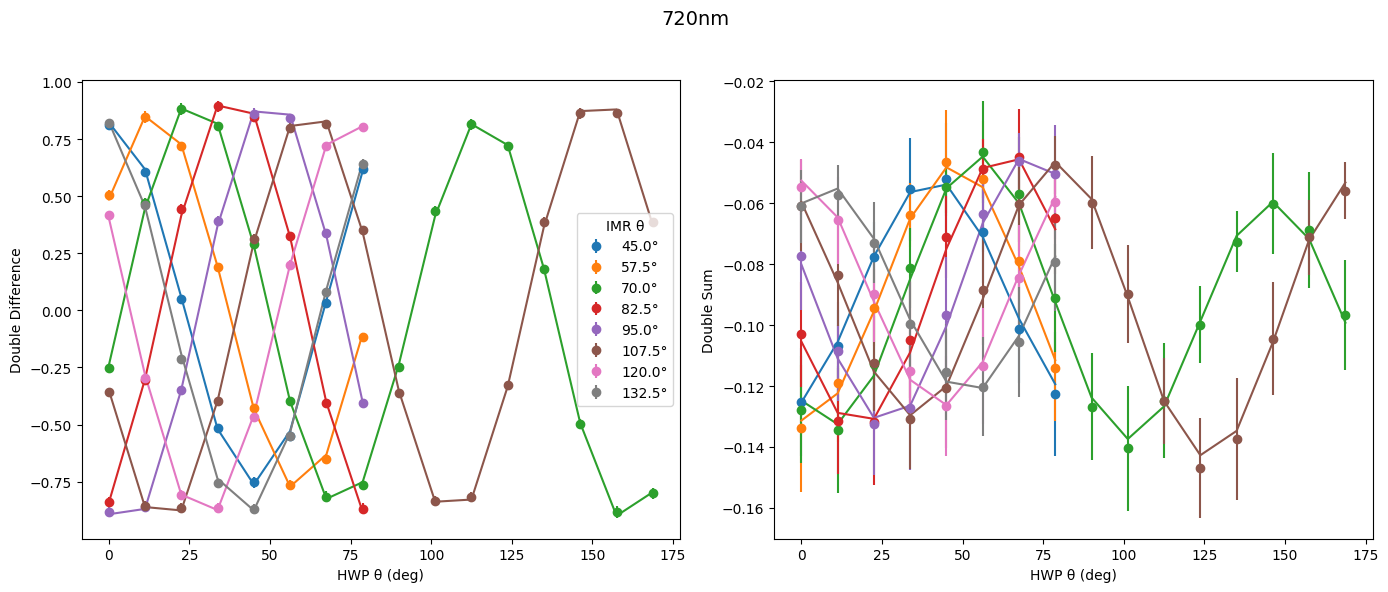

Before p0: {'dichroic': {'phi': -0.036613829319591285, 'epsilon': 0.30961271417406144, 'theta': -36.2029532633576}, 'flc': {'phi': 3.208264896294665, 'delta_theta': 1.3140778415749863}, 'optics': {'phi': 0.21284457814750607, 'epsilon': 0.004510520727400743, 'theta': 0.038748243569497146}, 'image_rotator': {'phi': 2.6262134407597992}, 'hwp': {'phi': 2.988779619314061, 'delta_theta': -2.040187445301089}, 'lp': {'theta': -0.12101730410478859}}
Iteration #: 9
logl_value: 15.910273038151773
Best Fit Parameters: [-3.66161734e-02  3.09611562e-01 -3.62029181e+01  3.20826139e+00
  1.31407125e+00  2.12840400e-01  4.51044010e-03  3.88779305e-02
  2.62621265e+00  2.98878002e+00 -2.04013357e+00 -1.20929658e-01]
After p0: {'dichroic': {'phi': -0.036616173439425304, 'epsilon': 0.3096115617464214, 'theta': -36.20291814697288}, 'flc': {'phi': 3.2082613947486154, 'delta_theta': 1.3140712491252144}, 'optics': {'phi': 0.21284040049313796, 'epsilon': 0.004510440096118253, 'theta': 0.038877930542039335}, 'i

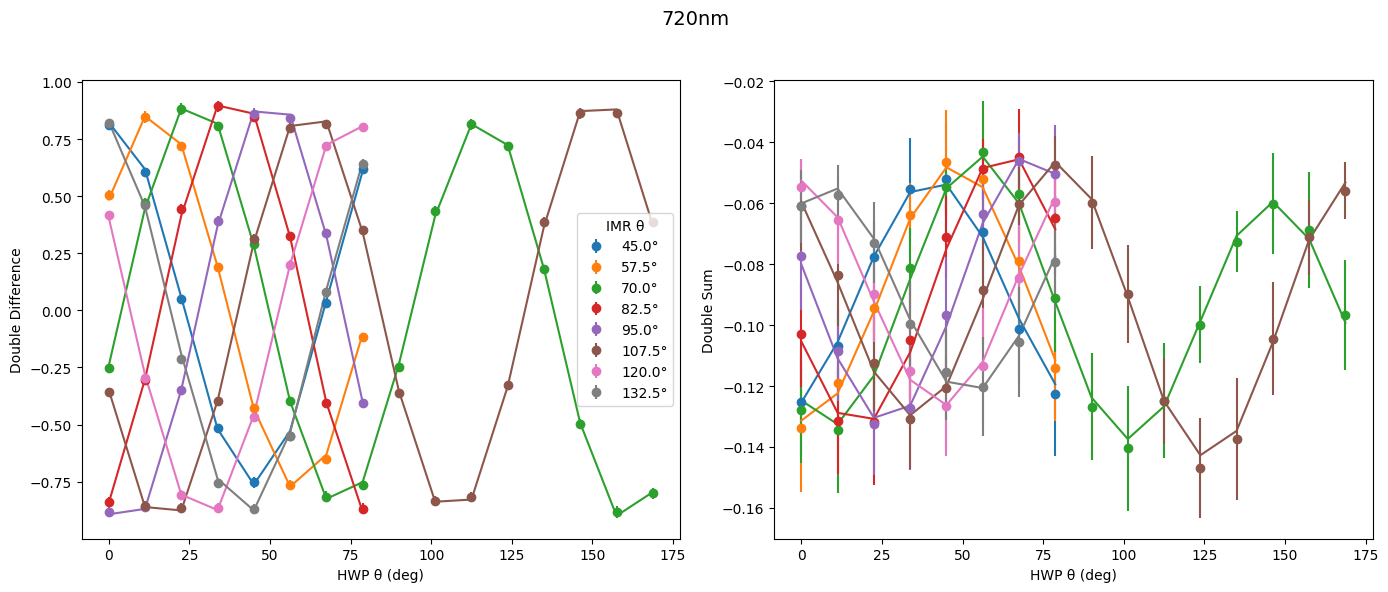

Before p0: {'dichroic': {'phi': -0.036616173439425304, 'epsilon': 0.3096115617464214, 'theta': -36.20291814697288}, 'flc': {'phi': 3.2082613947486154, 'delta_theta': 1.3140712491252144}, 'optics': {'phi': 0.21284040049313796, 'epsilon': 0.004510440096118253, 'theta': 0.038877930542039335}, 'image_rotator': {'phi': 2.6262126464081765}, 'hwp': {'phi': 2.9887800248296097, 'delta_theta': -2.040133571265055}, 'lp': {'theta': -0.12092965761243682}}
Iteration #: 10
logl_value: 15.910272960572588
Best Fit Parameters: [-3.66132324e-02  3.09610281e-01 -3.62028886e+01  3.20826623e+00
  1.31391355e+00  2.12843729e-01  4.51049506e-03  3.78283798e-02
  2.62621260e+00  2.98878043e+00 -2.03983831e+00 -1.20695104e-01]
After p0: {'dichroic': {'phi': -0.03661323244090525, 'epsilon': 0.3096102810158117, 'theta': -36.20288861473543}, 'flc': {'phi': 3.2082662283735797, 'delta_theta': 1.3139135496729648}, 'optics': {'phi': 0.21284372927881484, 'epsilon': 0.004510495058339451, 'theta': 0.03782837984118495}, '

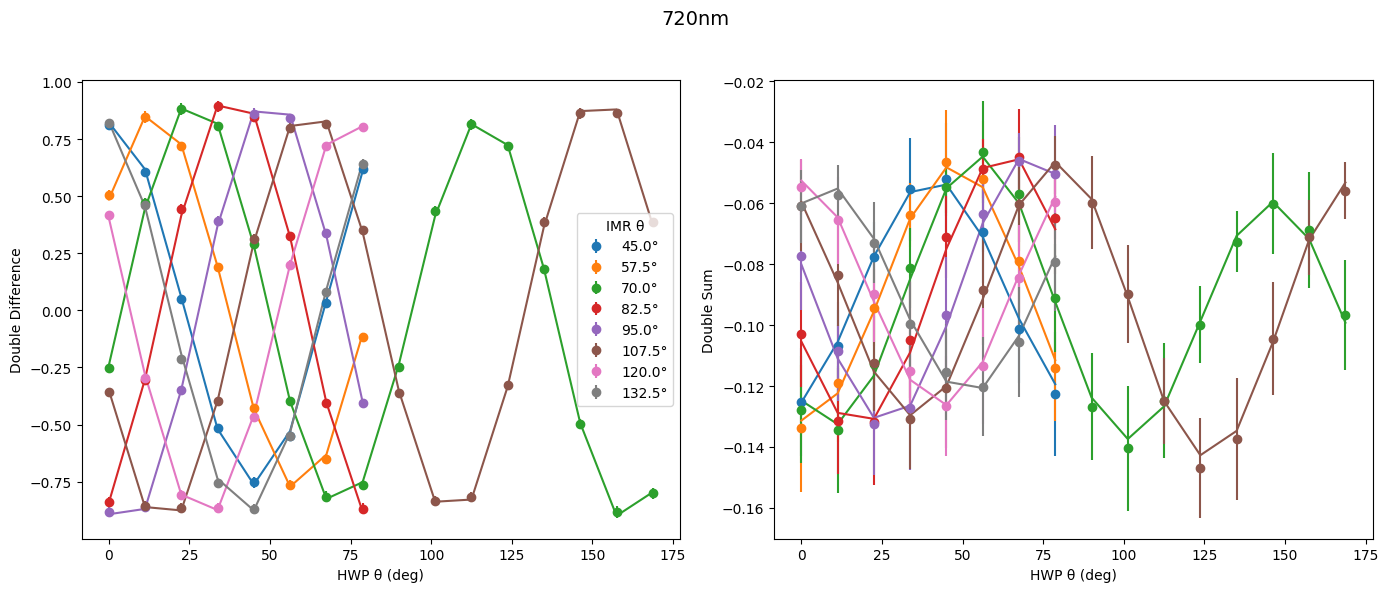

Before p0: {'dichroic': {'phi': -0.03661323244090525, 'epsilon': 0.3096102810158117, 'theta': -36.20288861473543}, 'flc': {'phi': 3.2082662283735797, 'delta_theta': 1.3139135496729648}, 'optics': {'phi': 0.21284372927881484, 'epsilon': 0.004510495058339451, 'theta': 0.03782837984118495}, 'image_rotator': {'phi': 2.6262125990853624}, 'hwp': {'phi': 2.988780430663745, 'delta_theta': -2.039838306076118}, 'lp': {'theta': -0.12069510441193818}}
Iteration #: 11
logl_value: 15.91027294376329
Best Fit Parameters: [-3.66142141e-02  3.09610315e-01 -3.62028793e+01  3.20826523e+00
  1.31392923e+00  2.12839079e-01  4.51065047e-03  3.78167781e-02
  2.62621246e+00  2.98878024e+00 -2.03982493e+00 -1.20643815e-01]
After p0: {'dichroic': {'phi': -0.03661421410513093, 'epsilon': 0.30961031539477596, 'theta': -36.202879293442166}, 'flc': {'phi': 3.2082652267904095, 'delta_theta': 1.313929234089686}, 'optics': {'phi': 0.21283907946441302, 'epsilon': 0.004510650471324302, 'theta': 0.03781677814448516}, 'ima

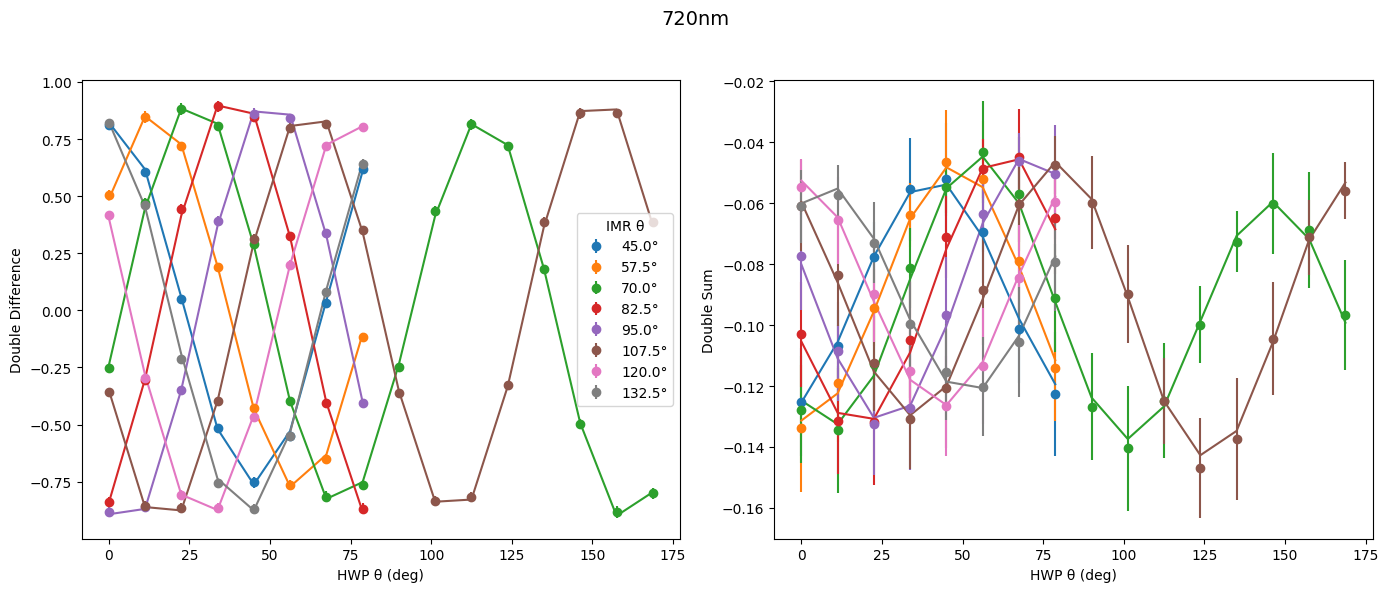

Before p0: {'dichroic': {'phi': -0.03661421410513093, 'epsilon': 0.30961031539477596, 'theta': -36.202879293442166}, 'flc': {'phi': 3.2082652267904095, 'delta_theta': 1.313929234089686}, 'optics': {'phi': 0.21283907946441302, 'epsilon': 0.004510650471324302, 'theta': 0.03781677814448516}, 'image_rotator': {'phi': 2.626212456286158}, 'hwp': {'phi': 2.9887802449000826, 'delta_theta': -2.039824931323823}, 'lp': {'theta': -0.12064381498467601}}
Iteration #: 12
logl_value: 15.910272934728019
Best Fit Parameters: [-3.66118438e-02  3.09611215e-01 -3.62029025e+01  3.20826933e+00
  1.31394954e+00  2.12840393e-01  4.51063074e-03  3.77676635e-02
  2.62621234e+00  2.98878027e+00 -2.03987299e+00 -1.20677582e-01]
After p0: {'dichroic': {'phi': -0.036611843805344046, 'epsilon': 0.309611215053783, 'theta': -36.202902530508126}, 'flc': {'phi': 3.2082693261992414, 'delta_theta': 1.3139495443705327}, 'optics': {'phi': 0.21284039287789375, 'epsilon': 0.004510630743509405, 'theta': 0.037767663545366384}, '

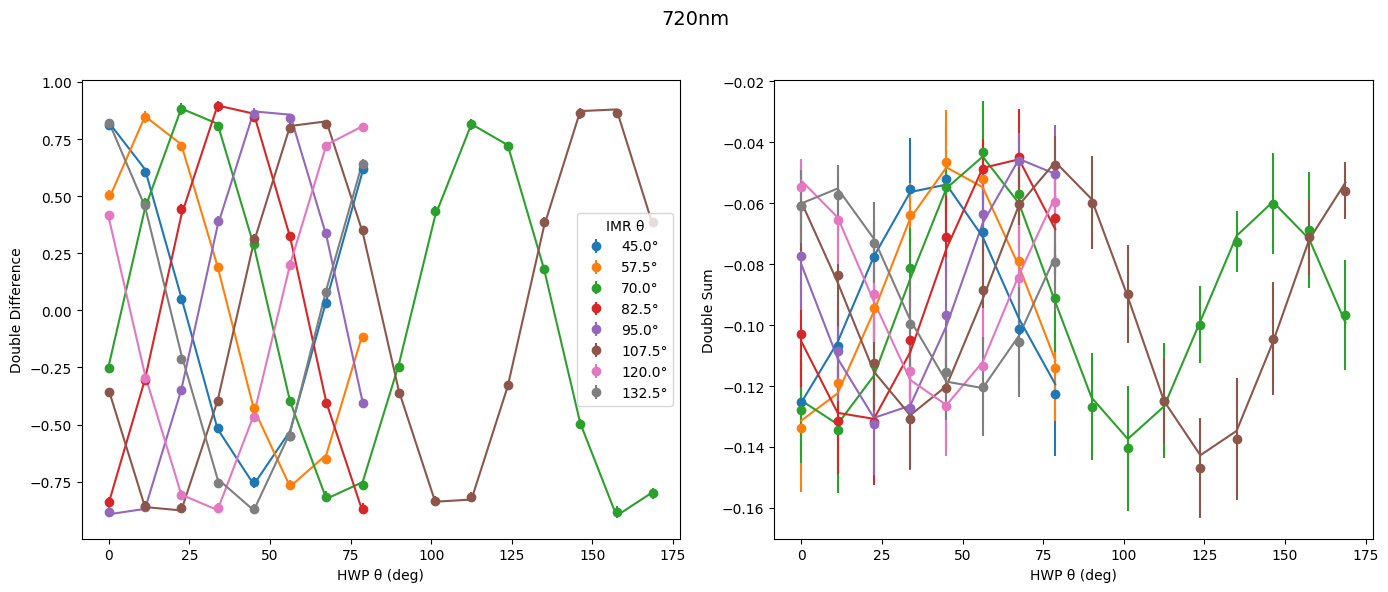

Before p0: {'dichroic': {'phi': -0.036611843805344046, 'epsilon': 0.309611215053783, 'theta': -36.202902530508126}, 'flc': {'phi': 3.2082693261992414, 'delta_theta': 1.3139495443705327}, 'optics': {'phi': 0.21284039287789375, 'epsilon': 0.004510630743509405, 'theta': 0.037767663545366384}, 'image_rotator': {'phi': 2.6262123404403983}, 'hwp': {'phi': 2.9887802680729645, 'delta_theta': -2.039872985005611}, 'lp': {'theta': -0.12067758172114157}}
Iteration #: 13
logl_value: 15.9102729139877
Best Fit Parameters: [-3.66140219e-02  3.09610432e-01 -3.62028864e+01  3.20826549e+00
  1.31397661e+00  2.12839253e-01  4.51050360e-03  3.80780639e-02
  2.62621199e+00  2.98878072e+00 -2.03983407e+00 -1.20551130e-01]
After p0: {'dichroic': {'phi': -0.03661402190565084, 'epsilon': 0.3096104319530364, 'theta': -36.202886431892054}, 'flc': {'phi': 3.208265485528148, 'delta_theta': 1.3139766107708652}, 'optics': {'phi': 0.21283925343695437, 'epsilon': 0.004510503598936958, 'theta': 0.03807806394942666}, 'im

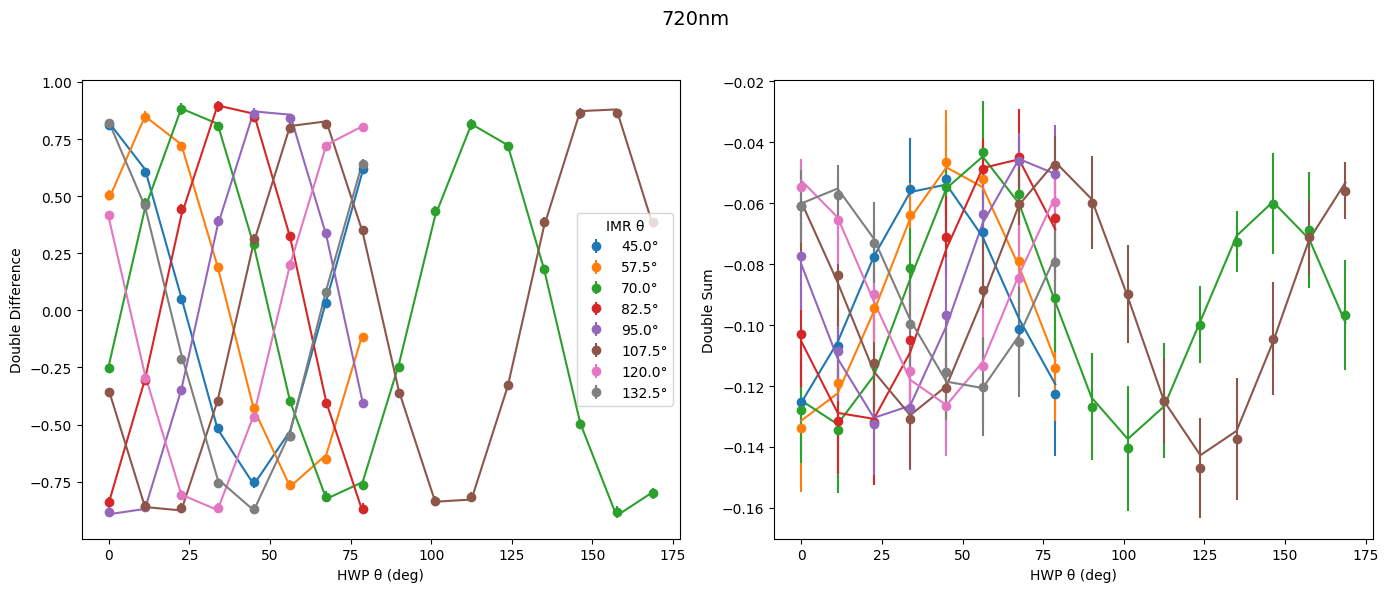

Before p0: {'dichroic': {'phi': -0.03661402190565084, 'epsilon': 0.3096104319530364, 'theta': -36.202886431892054}, 'flc': {'phi': 3.208265485528148, 'delta_theta': 1.3139766107708652}, 'optics': {'phi': 0.21283925343695437, 'epsilon': 0.004510503598936958, 'theta': 0.03807806394942666}, 'image_rotator': {'phi': 2.6262119861492064}, 'hwp': {'phi': 2.988780719500932, 'delta_theta': -2.0398340656144676}, 'lp': {'theta': -0.12055113028469933}}
Iteration #: 14
logl_value: 15.910272909127588
Best Fit Parameters: [-3.66137470e-02  3.09610744e-01 -3.62028939e+01  3.20826569e+00
  1.31399468e+00  2.12840801e-01  4.51052807e-03  3.82685757e-02
  2.62621229e+00  2.98878021e+00 -2.03985399e+00 -1.20542643e-01]
After p0: {'dichroic': {'phi': -0.036613746970734266, 'epsilon': 0.3096107443171094, 'theta': -36.20289385230354}, 'flc': {'phi': 3.2082656924616977, 'delta_theta': 1.313994680630473}, 'optics': {'phi': 0.21284080067138839, 'epsilon': 0.004510528073607487, 'theta': 0.03826857567855085}, 'im

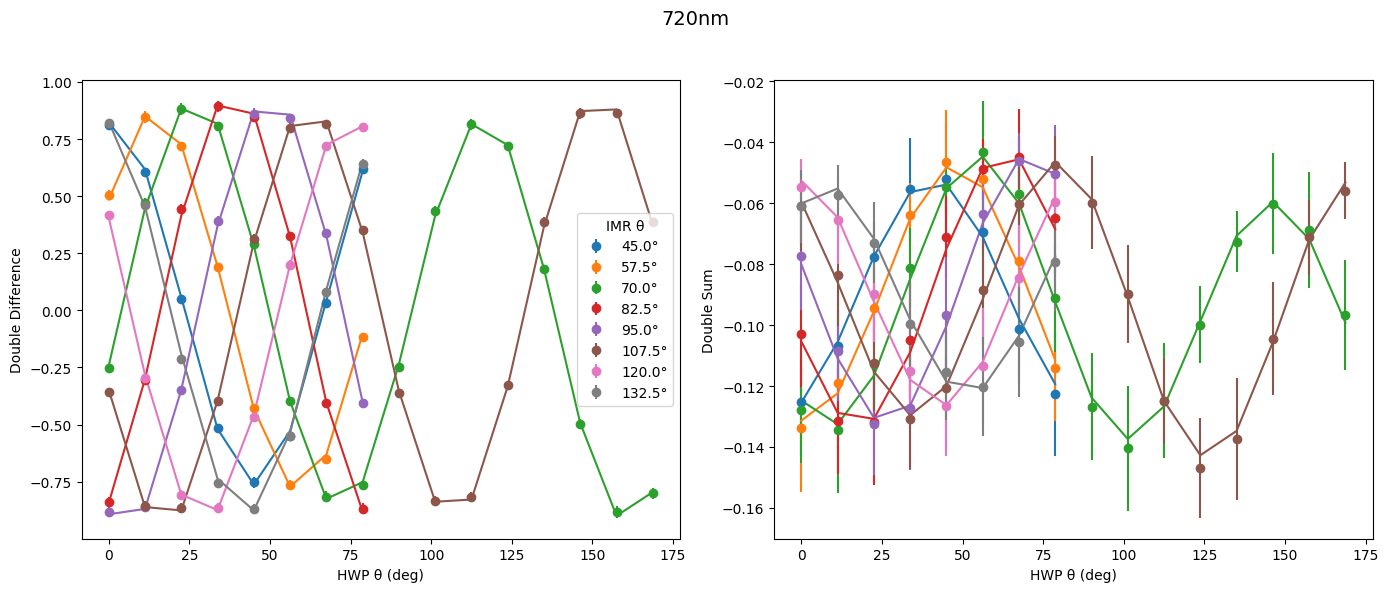

Before p0: {'dichroic': {'phi': -0.036613746970734266, 'epsilon': 0.3096107443171094, 'theta': -36.20289385230354}, 'flc': {'phi': 3.2082656924616977, 'delta_theta': 1.313994680630473}, 'optics': {'phi': 0.21284080067138839, 'epsilon': 0.004510528073607487, 'theta': 0.03826857567855085}, 'image_rotator': {'phi': 2.626212289968494}, 'hwp': {'phi': 2.988780211780839, 'delta_theta': -2.039853994189051}, 'lp': {'theta': -0.12054264254106475}}
Iteration #: 15
logl_value: 15.910272908202497
Best Fit Parameters: [-3.66152728e-02  3.09610910e-01 -3.62028973e+01  3.20826341e+00
  1.31399292e+00  2.12839674e-01  4.51053637e-03  3.83373064e-02
  2.62621231e+00  2.98878038e+00 -2.03982238e+00 -1.20489495e-01]
After p0: {'dichroic': {'phi': -0.0366152727888668, 'epsilon': 0.3096109097482581, 'theta': -36.20289727099215}, 'flc': {'phi': 3.208263411837663, 'delta_theta': 1.3139929216025346}, 'optics': {'phi': 0.21283967391430964, 'epsilon': 0.004510536374313613, 'theta': 0.03833730644631417}, 'image_

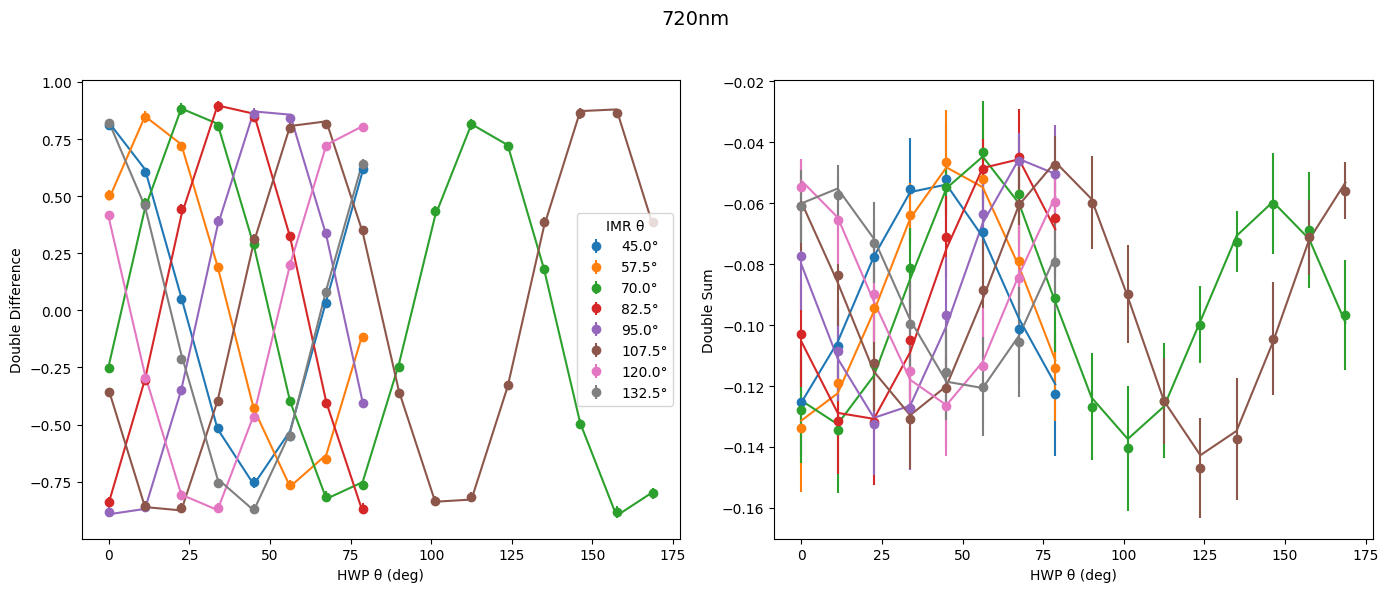

Before p0: {'dichroic': {'phi': -0.0366152727888668, 'epsilon': 0.3096109097482581, 'theta': -36.20289727099215}, 'flc': {'phi': 3.208263411837663, 'delta_theta': 1.3139929216025346}, 'optics': {'phi': 0.21283967391430964, 'epsilon': 0.004510536374313613, 'theta': 0.03833730644631417}, 'image_rotator': {'phi': 2.6262123083260356}, 'hwp': {'phi': 2.988780381579053, 'delta_theta': -2.0398223773601254}, 'lp': {'theta': -0.12048949510033102}}
Iteration #: 16
logl_value: 15.910272908202497
Best Fit Parameters: [-3.66152728e-02  3.09610910e-01 -3.62028973e+01  3.20826341e+00
  1.31399292e+00  2.12839674e-01  4.51053637e-03  3.83373064e-02
  2.62621231e+00  2.98878038e+00 -2.03982238e+00 -1.20489495e-01]
Stopping: logl did not improve over the previous iteration.


In [7]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (delta_derot - abs(delta_derot) * 0.1, delta_derot + abs(delta_derot) * 0.1),
    },
    "hwp": {
        "phi": (delta_HWP - abs(delta_HWP) * 0.1, delta_HWP + abs(delta_HWP) * 0.1),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Updating p0 and saving the latest best fit before plotting.
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = saved_fit_filename
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)
    print("Saved latest best fit to: " + filename)

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    iteration += 1


# Step 6: Plot model with best fit

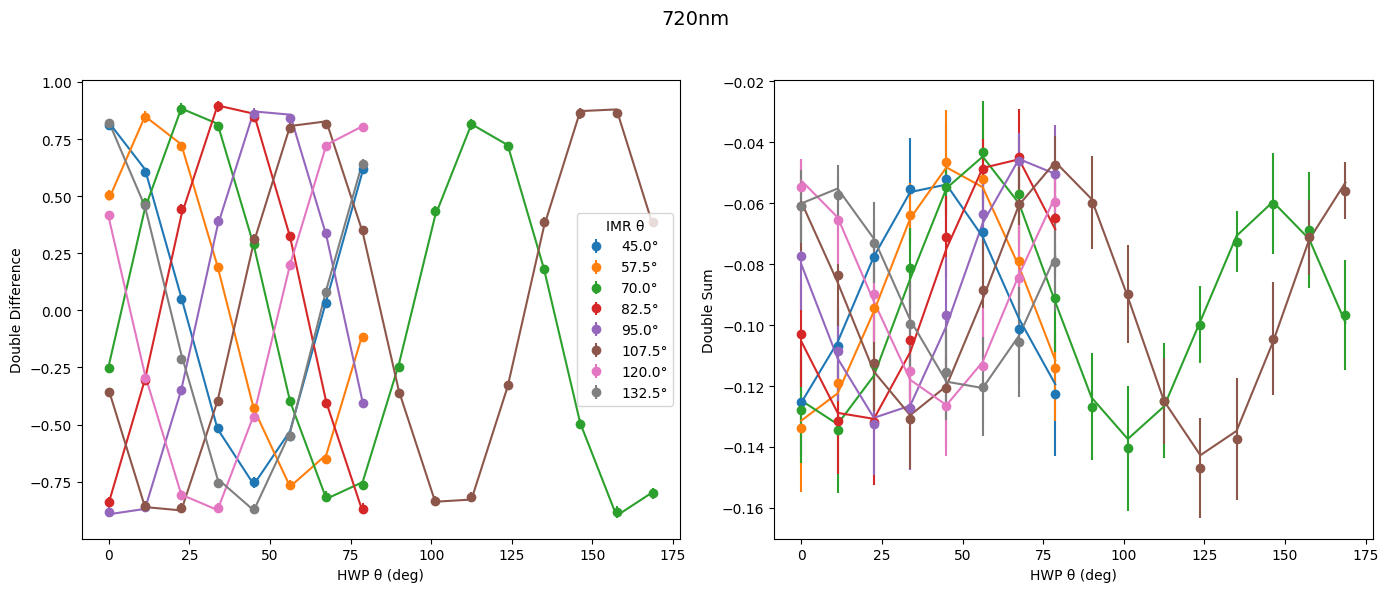

In [8]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)